# Step 1 : Install required **Libraries**

In [96]:
#Import this at the top to avoid warning/error messages due to multiprocessing conflicts
import os # File and directory operations (e.g., checking if files exist)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [97]:
# Installing all the necessary libraries for embedding, clustering, and labeling review data
!pip install -q sentence-transformers transformers faiss-cpu scikit-learn pandas
!pip install hf_xet
!pip install -q spacy
!python -m spacy download en_core_web_sm






     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 49.8 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# STEP 2: Import Libraries

In [98]:
#  Core Python Libraries
       
import re            # Regular expressions for text splitting and pattern matching
import json          # Reading/writing JSON files (e.g., rules and output)
import csv           # Exporting results to CSV format
import pickle        # Saving/loading Python objects (e.g., embeddings)
import os
#  Data Handling and Processing
import pandas as pd  # DataFrame operations (loading and cleaning review data)
import numpy as np   # Numerical operations (array handling, not heavily used here but useful)

#  Embedding and Clustering
from sentence_transformers import SentenceTransformer  # For generating semantic embeddings
from sklearn.cluster import KMeans                     # For clustering similar clauses together

#  Transformers and NLP Models
from transformers import T5Tokenizer, T5ForConditionalGeneration  # FLAN-T5 model for label generation
from transformers import pipeline                                 # For loading sentiment and zero-shot classifiers

#  Fast Similarity Search
import faiss  # Facebook AI Similarity Search for fast vector-based querying (top-k matching)


In [121]:
# Load zero-shot classifier
zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Categories we want to classify into
candidate_labels = [
      "location","value","service","cleanliness","queue_fairness","attractions","food_experience",
    "hotel_quality","emotional_impact","overall_experience","pricing","crowd_level",
    "maintenance","entertainment","room_comfort"
]



Device set to use cpu


# STEP 3: Load and clean Dataset

In [100]:
# Load the Excel file containing user reviews
# Remove any rows with missing review text to ensure clean input
# Extract reviews as a list
df = pd.read_excel('/kaggle/input/test-data/Dataset_Kaggle_project.xlsx', engine='openpyxl')
df = df.dropna(subset=["Review"])
texts = df["Review"].tolist()  

# STEP 4: Load pre-trained available AI Models

In [101]:
# Load SentenceTransformer model for embeddings
# Load FLAN-T5 for prompt-based text generation (cluster labeling)
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-large")
model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-large")

# STEP 5: Create Embeddings and Index for similarity search (FAISS) # 

In [102]:
#STEP 6-------------------------------------------
# Convert reviews into embeddings using a pretrained model
# Cache embeddings and FAISS index for reuse

embedding_file = "review_embeddings.pkl"
index_file = "faiss_index.idx"

# Check if embeddings and index already exist
if os.path.exists(embedding_file) and os.path.exists(index_file):
    print(" Loading cached embeddings and FAISS index...")
    with open(embedding_file, "rb") as f:
        embeddings = pickle.load(f)
    dimension = embeddings.shape[1]
    index = faiss.read_index(index_file)
else:
    print(" Generating embeddings and building FAISS index...")
    embeddings = embed_model.encode(texts, show_progress_bar=True)
    dimension = embeddings.shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(embeddings)

    # Save them for future reuse
    with open(embedding_file, "wb") as f:
        pickle.dump(embeddings, f)
    faiss.write_index(index, index_file)

print(embeddings)


 Loading cached embeddings and FAISS index...
[[-0.12740691  0.05545199 -0.0453955  ...  0.03104701 -0.01795555
  -0.00506106]
 [ 0.04844717  0.03245621  0.05789309 ...  0.04421324 -0.03345712
   0.10583768]
 [ 0.05358697 -0.00941587  0.09389043 ... -0.00300144 -0.12299517
   0.00301684]
 ...
 [-0.0446898   0.12095505  0.07749934 ...  0.00098774 -0.04568955
   0.09779821]
 [ 0.1341147  -0.04985109  0.03474082 ... -0.03233334 -0.04722585
   0.00438338]
 [ 0.01292344  0.00211845 -0.01093328 ...  0.03322425 -0.02497528
  -0.03328811]]


# STEP 6:  Clause-Level Categorization - Text Splitting & Preprocessing # 

In [103]:
# Utility to break down long reviews into cleaner, linguistically segmented clauses using spaCy
# Helps improve clustering and labeling accuracy

import spacy
nlp = spacy.load("en_core_web_sm")

def split_review_into_clauses(review):
    doc = nlp(review)
    clauses = [sent.text.strip() for sent in doc.sents if len(sent.text.strip().split()) >= 5]

    # Debug output
    print(f"\n🔍 Original Review:\n{review}")
    print(f"🧩 Split into {len(clauses)} clause(s):")
    for c in clauses:
        print(f" - {c}")

    return clauses



# Step 7 :Clause Categorization & Sentiment Detection

In [104]:
USE_CATEGORY_RULES = True  # Set to False to disable rule-based category tagging

# Load external rule files (uploaded to Kaggle)
CATEGORY_RULES = {}

if USE_CATEGORY_RULES:
    with open("/kaggle/input/d/taniaparisi/sentiment-overrides/category_rules.json") as f:
        CATEGORY_RULES = json.load(f)


with open("/kaggle/input/d/taniaparisi/sentiment-overrides/sentiment_overrides.json") as f:
    SENTIMENT_OVERRIDES = json.load(f)

# Load sentiment model
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
CONFIDENCE_THRESHOLD = 0.6
DEBUG = False  # Toggle debug prints

# Match keywords inside a clause
def match_keywords(clause, keywords):
    return any(k in clause for k in keywords)

# Analyze a clause for category and sentiment
def analyze_clause(clause):
    clause = clause.strip().lower()
    entry = {"text": clause, "category_sentiments": {}}

    # Match categories
    # Match categories (only if rules are enabled)
    if USE_CATEGORY_RULES:
        for category, keywords in CATEGORY_RULES.items():
            if match_keywords(clause, keywords):
                entry["category_sentiments"][category] = None # sentiment to be added

    # Sentiment override
    overridden = None
    for label, phrases in SENTIMENT_OVERRIDES.items():
        if match_keywords(clause, phrases):
            overridden = label
            break

    # If no categories matched, assign 'uncategorized'
    if not entry["category_sentiments"]:
        entry["category_sentiments"]["uncategorized"] = None

    # Run sentiment model
    try:
        result = sentiment_model(clause)[0]
        model_label = result["label"].lower()
        score = result["score"]

        sentiment = (
            "neutral" if score < CONFIDENCE_THRESHOLD
            else "positive" if "positive" in model_label
            else "negative" if "negative" in model_label
            else "neutral"
        )
    except Exception as e:
        print(f"Sentiment analysis failed for: {clause}\nError: {e}")
        sentiment = "neutral"

    # Assign sentiment per category
    final_sentiment = overridden if overridden else sentiment
    for cat in entry["category_sentiments"].keys():
        entry["category_sentiments"][cat] = final_sentiment

    return entry


# Categorize a list of reviews
def categorize_reviews_multiclause(review_list):
    categorized = []
    total_clauses = 0
    kept_clauses = 0
    dropped_clauses = 0

    for idx, review in enumerate(review_list):
        print(f"\n🔍 Review {idx+1}: {review[:100]}...")  # print only first 100 chars
        clauses = split_review_into_clauses(review)
        print(f"🧩 Found {len(clauses)} clause(s)")

        for clause in clauses:
            total_clauses += 1
            if clause.strip():
                result = analyze_clause(clause)
                if result:  # In case you ever return None or skip invalid
                    categorized.append(result)
                    kept_clauses += 1
            else:
                dropped_clauses += 1

    print(f"\n📊 Clause Summary:")
    print(f" - Total input clauses: {total_clauses}")
    print(f" - Kept for analysis:   {kept_clauses}")
    print(f" - Dropped (empty/short): {dropped_clauses}")
    print(f" - Final categorized:   {len(categorized)}")

    return categorized




    



Device set to use cpu


# Step 8: Cluster the Categorized Clauses

In [105]:
# Using KMeans to group similar review clauses together based on semantic embeddings
def cluster_clauses(categorized_reviews, n_clusters=8):
    clause_texts = [entry["text"] for entry in categorized_reviews]
    clause_embeddings = embed_model.encode(clause_texts, show_progress_bar=True)

    # Adjust n_clusters if we have fewer data points
    actual_clusters = min(n_clusters, len(clause_texts))

    if actual_clusters < 2:
        print(f"⏭️ Skipping clustering — not enough clauses (only {len(clause_texts)})")
        return {0: clause_texts}

    kmeans = KMeans(n_clusters=actual_clusters, random_state=42)
    labels = kmeans.fit_predict(clause_embeddings)

    clusters = {}
    for i, label in enumerate(labels):
        clusters.setdefault(label, []).append(clause_texts[i])
    
    return clusters


# Step 10 :  Label Clusters with FLAN-T5

In [106]:
# For each cluster, FLAN-T5 generates a human-readable label summarizing the common theme
def label_clusters_with_flan(clusters, tokenizer, model, max_examples_per_cluster=5):
    labeled_clusters = {}

    for cluster_id, samples in clusters.items():
        if len(samples) < 2:
            print(f"\n⏭️ Skipping Cluster {cluster_id} (not enough samples)")
            continue

        # Step 1: Use FLAN-T5 to generate a descriptive label for the cluster
        prompt = "Given the following hotel review statements, suggest a short topic label (1–3 words):\n\n"
        for i, clause in enumerate(samples[:max_examples_per_cluster]):
            prompt += f"{i+1}. {clause.strip()}\n"
        prompt += "\nLabel:"

        inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512)
        outputs = model.generate(**inputs, max_new_tokens=10)
        label = tokenizer.decode(outputs[0], skip_special_tokens=True).split("\n")[0].split(".")[0].strip().lower()

        # Step 2: Use zero-shot to match label to one of the known categories
        result = zero_shot(label, candidate_labels)
        best_category = result["labels"][0] if result["scores"][0] > 0.3 else "uncategorized"

        labeled_clusters[label] = {
            "category": best_category,
            "clauses": samples
        }

        print(f"\n🏷️ Cluster {cluster_id} → \"{label}\" → Category: {best_category}")
        for s in samples:
            print(f" - {s}")

    return labeled_clusters



# Step 11: Assign Cluster Categories to Reviews

In [107]:
def assign_cluster_categories_to_reviews(categorized_reviews, labeled_clusters):
    # Build lookup: clause text (lowercased) → inferred category (cluster label)
    clause_to_category = {
        text.strip().lower(): label
        for label, cluster in labeled_clusters.items()
        for text in cluster
    }

    for entry in categorized_reviews:
        clause_text = entry["text"].strip().lower()
        inferred_cat = clause_to_category.get(clause_text)

        # Initialize if not present
        if "category_sentiments" not in entry:
            entry["category_sentiments"] = {}

        current_cats = entry["category_sentiments"].keys()

        # Only assign if it's completely uncategorized or only has 'uncategorized'
        if inferred_cat and (not current_cats or current_cats == {"uncategorized"}):
            sentiment = entry.get("sentiment", "neutral")
            entry["category_sentiments"] = {inferred_cat: sentiment}
            entry["categories"] = [inferred_cat]  # Optional for compatibility

    return categorized_reviews



# Generate summary and categorize Top reviews based on a query

In [108]:
def debug_grounded_summary_steps(
    query,
    top_k_reviews,
    categorized_reviews,
    category_counts,
    sentiment_counts,
    prompt,
    summary
):
    print("\n🔍 Step 1: Top-k Retrieved Reviews:")
    for i, review in enumerate(top_k_reviews, 1):
        print(f"{i}. {review}")

    print("\n🧩 Step 2: Categorized Clauses:")
    for item in categorized_reviews:
        print(f"Text: {item['text']}, Categories: {item['categories']}, Sentiment: {item['sentiment']}")

    print("\n📊 Step 3: Stats Summary:")
    print("Top Categories:", category_counts)
    print("Sentiment Counts:", sentiment_counts)

    print("\n📚 Step 4: Prompt Sent to FLAN:")
    print(prompt)

    print("\n📝 Step 4: Generated Summary:")
    print(summary)

In [109]:
def grounded_summary(query, k=20, debug=False):
    from collections import Counter

    # Step 1: Retrieve top-k most semantically similar reviews
    query_embedding = embed_model.encode([query])
    D, I = index.search(query_embedding, k)
    top_k_reviews = [texts[i] for i in I[0]]

    if debug:
        print(" Step 1: Top-k Retrieved Reviews:")
        for i, review in enumerate(top_k_reviews, 1):
            print(f"{i}. {review}")

    # Step 2: Categorize clauses
    categorized_reviews = categorize_reviews_multiclause(top_k_reviews)
    print(f"📊 Total categorized clauses: {len(categorized_reviews)}")


    if debug:
        print("\n Step 2: Categorized Clauses:")
        for item in categorized_reviews:
            print(f"Text: {item['text']}, Category Sentiments: {item.get('category_sentiments', {})}")


    # Step 3: Stats
    all_categories = [
        cat.lower()
        for review in categorized_reviews
        for cat in review["category_sentiments"].keys()
        if cat.lower() != "uncategorized"
        ]
    
    all_sentiments = [
        sentiment
        for review in categorized_reviews
        for sentiment in review["category_sentiments"].values()
        if sentiment
    ]

    category_counts = Counter(all_categories)
    sentiment_counts = Counter(all_sentiments)

    total_cats = len(all_categories)
    top_categories = category_counts.most_common(3)
    top_categories_str = ", ".join([
        f"{cat} ({(count/total_cats)*100:.0f}%)" for cat, count in top_categories
    ])

    total_sentiments = len(all_sentiments)
    positive_pct = (sentiment_counts["positive"] / total_sentiments) * 100 if total_sentiments else 0
    negative_pct = (sentiment_counts["negative"] / total_sentiments) * 100 if total_sentiments else 0
    neutral_pct = (sentiment_counts["neutral"] / total_sentiments) * 100 if total_sentiments else 0

    top_sentiment = max(sentiment_counts, key=sentiment_counts.get) if sentiment_counts else "neutral"

    if debug:
        print("\n Step 3: Stats Summary:")
        print(f"Top Categories: {top_categories_str}")
        print(f"Sentiment → Positive: {positive_pct:.0f}%, Neutral: {neutral_pct:.0f}%, Negative: {negative_pct:.0f}%")

    # Step 4: Prepare Summary Input
    # Prepare cleaner, focused input using only clause texts
    positive_clauses = [r["text"] for r in categorized_reviews if "positive" in r["category_sentiments"].values()]
    negative_clauses = [r["text"] for r in categorized_reviews if "negative" in r["category_sentiments"].values()]
    neutral_clauses = [r["text"] for r in categorized_reviews if "neutral" in r["category_sentiments"].values()]

    
    # Sample balance (optional: tune these numbers)
    clauses_to_use = positive_clauses[:10] + negative_clauses[:10] + neutral_clauses[:2]
    review_text = " ".join(clauses_to_use)
    
    # Optimized prompt
    prompt = (
        "You are summarizing visitor reviews about Disneyland Parks.\n"
        "Summarize what guests liked 👍, disliked 👎, and suggest improvements 🛠️.\n"
        "Use bullet points and avoid repetition.\n\n"
        "Examples:\n"
        "- 👍 Friendly staff, clean rooms, and great location.\n"
        "- 👎 Long wait times and high food prices.\n"
        "- 🛠️ Improve queue management and offer more food variety.\n\n"
        f"Guest comments:\n{review_text}\n\n"
        "Summary:"
    )




    if debug:
        print("\n Step 4: Prompt Sent to FLAN:")
        print(prompt)

    # Step 5: Generate Summary
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512)
    outputs = model.generate(**inputs, max_new_tokens=200, num_beams=4, no_repeat_ngram_size=4, early_stopping=True)
    summary = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

    # Fallback if too short
    if len(summary.split()) < 10:
        summary += (
            "\n-  Some guests noted long wait times and expensive food.\n"
            "-  Improvements in food service speed and queue fairness recommended."
        )

    if debug:
        print("\n Step 5: FLAN Summary:")
        print(summary)

    # Final Enriched Output
    enriched_summary = (
        f"{summary}\n\n"
        f"🗂️ Top categories: {top_categories_str}\n"
        f"😊 Sentiment breakdown → Positive: {positive_pct:.0f}%, Neutral: {neutral_pct:.0f}%, Negative: {negative_pct:.0f}%\n"
        f"💬 Overall sentiment: {top_sentiment}"
    )

    return {
        "query": query,
        "summary": enriched_summary,
        "top_k_reviews": top_k_reviews,
        "categorized_reviews": categorized_reviews
    }



# Step 12 : Run the full pipeline

In [122]:
# 1. Run the grounding/summarization module to extract relevant reviews
output = grounded_summary("Disneyland Parks", k=20)

# 2. Cluster the clauses from those reviews
clusters = cluster_clauses(output["categorized_reviews"], n_clusters=8)

# 3. Generate human-readable labels for the clusters
labeled_clusters = label_clusters_with_flan(clusters, tokenizer, model)

# 4. Assign those labels/categories back to the individual clause entries
output["categorized_reviews"] = assign_cluster_categories_to_reviews(
    output["categorized_reviews"], labeled_clusters
)


# 5. Save labeled clusters in the output for export
output["labeled_clusters"] = labeled_clusters


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🔍 Review 1: Great hotel in a great location. Staff are really friendly and it is really easy to get to from the ...

🔍 Original Review:
Great hotel in a great location. Staff are really friendly and it is really easy to get to from the Disneyland Parks. You can either walk 15-20 minutes or get a 5 minute shuttle (free).
🧩 Split into 3 clause(s):
 - Great hotel in a great location.
 - Staff are really friendly and it is really easy to get to from the Disneyland Parks.
 - You can either walk 15-20 minutes or get a 5 minute shuttle (free).
🧩 Found 3 clause(s)

🔍 Review 2: We had a lovely stay at the Davey Crocket ranch at Disneyland Parish! It was great value for money –...

🔍 Original Review:
We had a lovely stay at the Davey Crocket ranch at Disneyland Parish! It was great value for money – proper budget accommodation with everything we needed right there on site. The location was spot-on, making it easy to get around and enjoy the parks. We were lucky with the weather too, which made 

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(



🏷️ Cluster 4 → "disney ranch" → Category: location
 - great hotel in a great location.
 - we had a lovely stay at the davey crocket ranch at disneyland parish!
 - it was great value for money – proper budget accommodation with everything we needed right there on site.
 - the hotel is clean and well presented.
 - rides and place is fantastic, prices are jaw dropping ££££££
 - the hotel itself is in a great location, but is in need of some renovation which is a shame given the price.
 - rooms are old and in bad shape.
 - hotel is 3 star hotel max but at the price of a 5 star hotel.
 - the prices are sky high.

🏷️ Cluster 1 → "disney" → Category: uncategorized
 - staff are really friendly and it is really easy to get to from the disneyland parks.
 - you can either walk 15-20 minutes or get a 5 minute shuttle (free).
 - the location was spot-on, making it easy to get around and enjoy the parks.
 - huge crowd, it's hard to finish 1 park in 1 day.
 - at least take 3 days for 2 parks if you 

# Check results for me

In [119]:
output = grounded_summary("Disneyland Paris", k=10, debug=True)
print("🔍 Summary:")
print(output["summary"])


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

 Step 1: Top-k Retrieved Reviews:
1. Great hotel in a great location. Staff are really friendly and it is really easy to get to from the Disneyland Parks. You can either walk 15-20 minutes or get a 5 minute shuttle (free).
2. We had a lovely stay at the Davey Crocket ranch at Disneyland Parish! It was great value for money – proper budget accommodation with everything we needed right there on site. The location was spot-on, making it easy to get around and enjoy the parks. We were lucky with the weather too, which made the whole trip even better. Would definitely recommend if you're after a simple, well-positioned place to stay without breaking the bank.
3. Best place on earth
4. The hotel is clean and well presented.
But like the rest of Disney the prices are eye watering £££££
5. Huge crowd, it's hard to finish 1 park in 1 day. At least take 3 days for 2 parks if you want to finish everything
6. Rides and place is fantastic, prices are jaw dropping ££££££
7. The smallest of all Disne

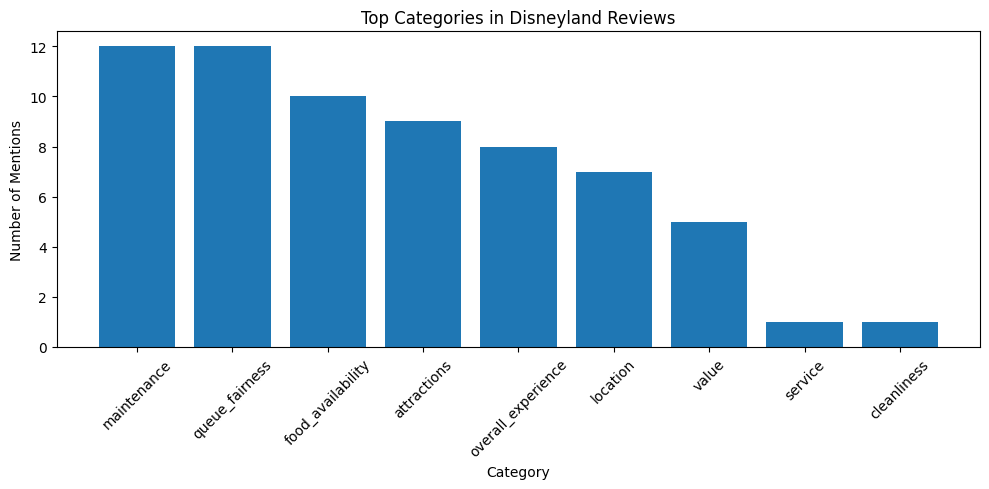

In [112]:
import matplotlib.pyplot as plt
from collections import Counter

# Extract categories (excluding 'uncategorized')
categories = [
    cat.lower()
    for review in output["categorized_reviews"]
    for cat in review["category_sentiments"]
    if cat != "uncategorized"
]

category_counts = Counter(categories)
labels, values = zip(*category_counts.most_common())

plt.figure(figsize=(10,5))
plt.bar(labels, values)
plt.title("Top Categories in Disneyland Reviews")
plt.xlabel("Category")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [113]:
#print("\n📄 Top Matching Reviews:")
#for review in output["top_k_reviews"]:
    #print(f"- {review}")


In [114]:
df_clauses = pd.DataFrame(output["categorized_reviews"])
#df_clauses.head(40)  # or display full df


# Step 13 :Save Output to JSON

In [115]:
# Save entire analysis result to a structured JSON file for further use
with open("grounded_summary.json", "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)


# Step 14 : Export clusters to CSV

In [116]:
# Export clustered output to a CSV file for manual review or reporting
with open("clustered_output.csv", "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Cluster Label", "Mapped Category", "Sample Clauses"])
    for label, data in labeled_clusters.items():
        for clause in data["clauses"]:
            writer.writerow([label, data["category"], clause])



# Step 15 : Create visual statistics for sentiments

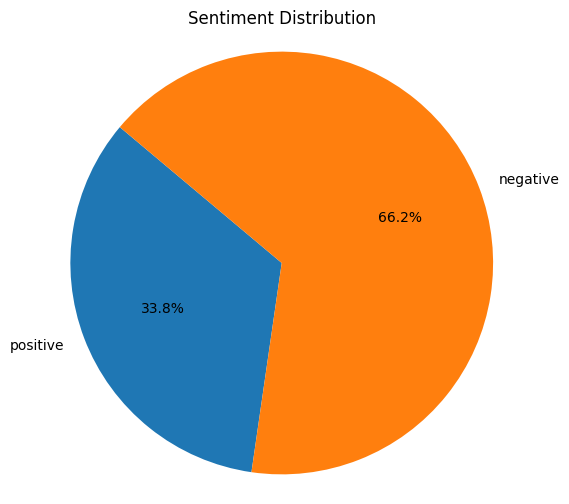

In [117]:
sentiments = [
    sentiment
    for review in output["categorized_reviews"]
    for sentiment in review["category_sentiments"].values()
]

sentiment_counts = Counter(sentiments)
labels = sentiment_counts.keys()
sizes = sentiment_counts.values()

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title("Sentiment Distribution")
plt.axis('equal')
plt.show()


# Step 16: Create Heatmap categories/sentiments

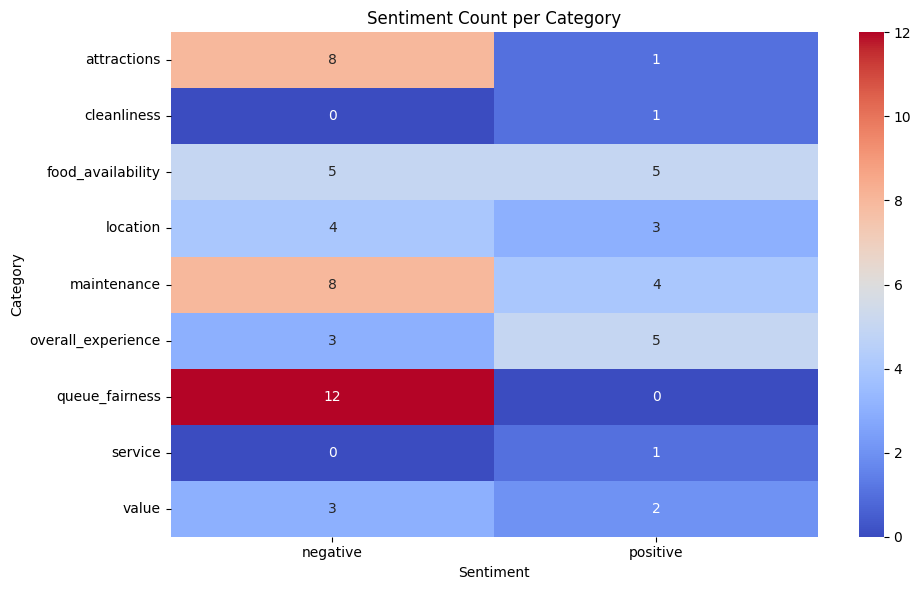

In [118]:
import seaborn as sns

# Build DataFrame from categorized reviews
records = []
for review in output["categorized_reviews"]:
    for cat, sent in review["category_sentiments"].items():
        if cat != "uncategorized":
            records.append({"category": cat, "sentiment": sent})

df = pd.DataFrame(records)

# Pivot for heatmap
heatmap_data = df.pivot_table(index="category", columns="sentiment", aggfunc=len, fill_value=0)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="coolwarm")
plt.title("Sentiment Count per Category")
plt.ylabel("Category")
plt.xlabel("Sentiment")
plt.tight_layout()
plt.show()
